In [31]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [32]:
data_train=data.sample(frac=0.67)
data_test=data.sample(frac=0.33)

In [33]:
data_train.head()

,area,bedrooms,age,location,price
57,79.397429,3,6.387858,3.683271,170.776031
208,50.759238,3,2.872395,8.378941,191.474722
96,128.409924,3,3.469336,9.455086,230.737778
258,135.509176,3,6.536873,4.035025,215.947937
229,144.670794,2,17.655975,10.000000,230.845068


In [34]:
import numpy as np
import pandas as pd


In [35]:
#get ready

In [36]:
def normalize(x):
    return (x-x.mean())/x.std()

In [37]:
#似乎与标准化也有关系，正常的标准化做的太离谱，s形状，但我这里不要S啊。/max /mean都试了
#正常的标准化0-1之间(x-x.min())/(x.max()-x.min())也不行

In [38]:
data_normalized=data_train.apply(normalize,axis=0)
data_normalized.head()

,area,bedrooms,age,location,price
57,-1.059461,0.222235,-0.401316,-1.337162,-1.027266
208,-1.706539,0.222235,-0.755096,1.083131,-0.593884
96,0.047971,0.222235,-0.695023,1.637809,0.228192
258,0.208378,0.222235,-0.386320,-1.155857,-0.081473
229,0.415384,-0.787240,0.732656,1.918675,0.230438


In [39]:
rng=np.random.default_rng(17)
primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645],
       [0.06113431, 0.07363859, 0.00152897, 0.02540409, 0.06041459,
        0.00837367, 0.09977637],
       [0.08323461, 0.00367774, 0.05675398, 0.06093401, 0.00069266,
        0.01790839, 0.01649222],
       [0.04619579, 0.05670036, 0.04519092, 0.09197757, 0.08149242,
        0.04011661, 0.02031616]]), 'threshold1': array([0.03583255, 0.0862035 , 0.03488156, 0.09910656, 0.05657688,
       0.02368459, 0.06586973]), 'power2': array([0.06602265, 0.05146076, 0.0279093 , 0.06299182, 0.04791908,
       0.06532888, 0.05422403]), 'threshold2': array([0.01212111])}


In [40]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [41]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [42]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [43]:
def standard_BP(data,primary_parameter,turn):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    if turn%200==0:
        print(get_loss(y,y_hat))
    
    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter    

In [44]:
for j in range(10):
    for i in range(len(data_train)):
        primary_parameter=\
        standard_BP(data_normalized.iloc[i],primary_parameter,i)
print(primary_parameter)
        

0.7325622776090035
0.09907994725232516
0.052210131799434685
0.0037814111577966526
0.0072044468362363855
0.0038746269998229995
0.006396551033429795
0.0040086225600652805
0.005871666880880463
0.004145875847066968
0.005488158159426892
0.0043124046319067124
0.005195461810440417
0.004530448674688852
0.004970211348180773
0.004821713068161607
0.004800718959642175
0.00520963377129212
0.004678585905381042
0.005718140830846967
{'power1': array([[ 1.24125373, -0.15417349, -0.74867775,  0.72507846,  0.33553223,
         0.37225678,  0.48401874],
       [ 0.30139179, -0.0629387 , -0.65571138,  0.32302506,  0.29524623,
         0.24330869,  0.4020584 ],
       [ 0.04036153,  0.03927838,  0.3309305 , -0.22981466, -0.16376333,
        -0.15126181, -0.21947938],
       [ 0.18311615,  0.0569691 , -0.09695378,  0.54740683,  0.32085288,
         0.30063393,  0.36431226]]), 'threshold1': array([-0.11667069,  0.46839942,  0.58989536,  0.28624918,  0.43234594,
        0.41113599,  0.38632947]), 'power2': arr

In [45]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [46]:
dataTest_normalized=normalize(data_test)
dataTest_normalized.head()

,area,bedrooms,age,location,price
377,-1.493815,0.270663,-0.996353,-0.900586,-1.390351
215,-0.789434,1.291447,1.518629,0.090698,-0.566789
266,0.724049,-0.750122,-0.834447,-1.572893,-1.155489
38,0.681970,0.270663,-0.230072,-0.685615,0.311540
237,-1.490378,-0.750122,0.197028,1.905157,-0.883789


In [47]:
dataTest_preduction=dataTest_normalized.apply(test_standardBP,axis=1,args=(primary_parameter,))
dataTest_preduction.head()

377   -1.010139
215   -0.116118
266    0.285735
38     0.921381
237   -0.812837
dtype: float64

In [48]:
def ab_normalize(data_preduction,data):
    data=data.iloc[:,-1]
    return data_preduction*data.std()+data.mean()

In [49]:
price_preduction=dataTest_preduction.apply(ab_normalize,args=(data_test,))

In [50]:
price_preduction.name='price_preduction'
price_preduction.head()

377    164.651328
215    208.445806
266    228.131023
38     259.268776
237    174.316349
Name: price_preduction, dtype: float64

In [51]:
result=pd.concat([data_test,price_preduction],axis=1)
result.head()

,area,bedrooms,age,location,price,price_preduction
377,53.490790,3,1.131470,4.203064,146.026256,164.651328
215,85.587363,4,25.935836,6.251153,186.369271,208.445806
266,154.552361,2,2.728291,2.814013,157.531195,228.131023
38,152.634954,3,8.689024,4.647215,229.395084,259.268776
237,53.647395,2,12.901364,10.000000,170.840683,174.316349


In [52]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price', ylabel='price_preduction'>

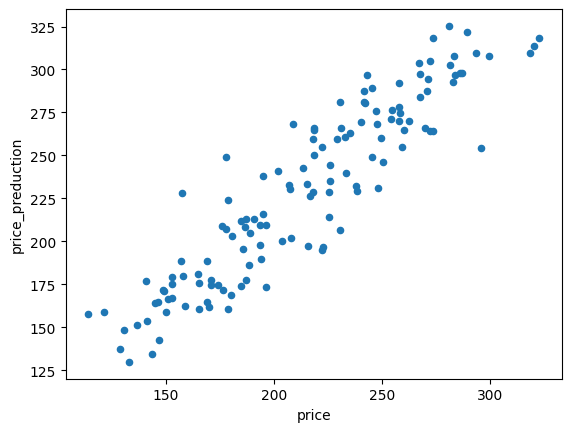

In [53]:
result.plot(kind='scatter',x='price',y='price_preduction')